## Imports

In [26]:
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

import os
from zipfile import ZipFile

from models import get_model
from trainers import get_trainer
from evaluation import *
from data import Augmentor

## Constants/Config

In [27]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
DATA_ZIP_PATH = "./datasets/CDNet"
DATASET_NAME = "highway"
DIMS = (128, 128)

DATASET_PATH = os.path.join(DATA_ZIP_PATH, DATASET_NAME)
print(f"Using device: {DEVICE}\n")
print(torch.version.cuda)

Using device: cuda

13.0


## Download data

In [28]:
if os.path.exists(DATA_ZIP_PATH) is False:
    with ZipFile(f"{DATA_ZIP_PATH}.zip", 'r') as zip:
        zip.extractall("./datasets/")

# TODO: zips have missing ground truths

Initialized Augmentor with source: ./datasets/CDNet\highway, initial dimensions: (240, 320)
Augmented dataset found at: ./datasets/CDNet\highway_Rot0_TPS0.7_El0_DN0
Loaded Flat Dataset: 1231 images from 'input'.
Visualizing images from local index 0...


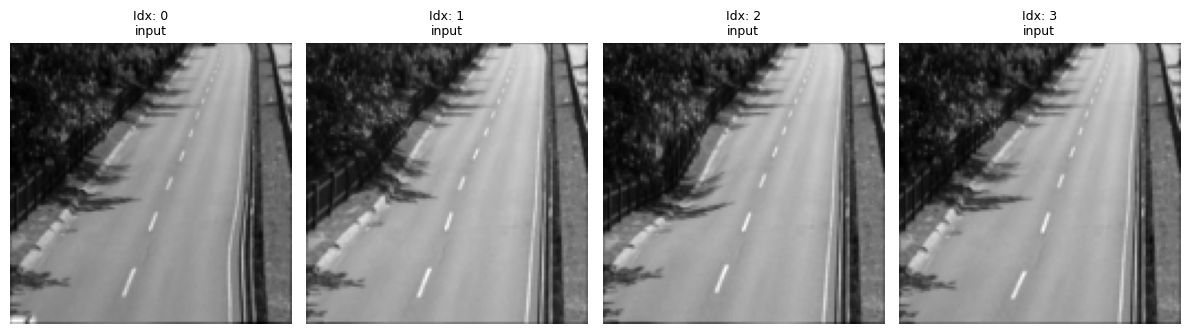

In [29]:
aug = Augmentor(rotation=0, tps=0.7, elastic=0, source_root=DATASET_PATH, device=DEVICE)
# aug.prepare(force_rebuild=True)

data = aug.get_dataset(
    transform=transforms.Compose([
        transforms.Resize(DIMS),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor()
    ])
)

train_loader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
eval_loader = DataLoader(data, batch_size=len(data), shuffle=False, num_workers=0)

data.visualise(num_images=4)

In [30]:
rda_params = {
        'latent_dim': 32,
        'dropout': 0,
        'std': 0.0,
        'lr': 2e-4,
        # 'lambda_': 0.003,
        'lambda_': 1.0 / torch.sqrt(torch.tensor(DIMS[0])),
        'outer_epochs': 25,
        'inner_epochs': 10,
    }
print(rda_params['lambda_'])

tensor(0.0884)


In [31]:
models_dict = {}
torch.cuda.empty_cache()

In [32]:
rpca = get_model('RPCA', max_iter=6000, lambda_=None, tol=1e-7).to(DEVICE)

torch.cuda.empty_cache()

In [33]:
# print(f"Using parameters: {rda_params}\n")

# rda = get_model('RDA', input_shape=DIMS, latent_dim=rda_params['latent_dim'], dropout=rda_params['dropout'], std=rda_params['std']).to(DEVICE)
# rda_trainer = get_trainer('RDA', rda, train_loader)
# rda_trainer.fit(
#     outer_epochs=rda_params['outer_epochs'], 
#     inner_epochs=rda_params['inner_epochs'],
#     lr=rda_params['lr'],
#     lambda_=rda_params['lambda_']
# )    
# models_dict['RDA'] = rda

# torch.cuda.empty_cache()

In [ ]:
# lambda_ = 0.9
# cevae = get_model('ceVAE', latent_channels=1024).to(DEVICE)
# cevae_trainer = get_trainer('ceVAE', cevae, train_loader)
# cevae_trainer.fit(epochs=60, lambda_=lambda_, lr=2e-4) #higher lambda = more weight to ce task
# models_dict['ceVAE'] = cevae

cevae = get_model('ceVAE', latent_channels=1024).to(DEVICE)
cevae.load_state_dict(torch.load("saved/testlambda085ssim.pth", map_location=DEVICE))
models_dict['ceVAE'] = cevae

torch.cuda.empty_cache()

In [ ]:
for model in models_dict.values():
    model.eval()

batch = next(iter(eval_loader))
X_input, _, _ = batch 

print(f"\nEvaluating on batch of size {X_input.shape[0]}...")
results_root = os.path.abspath(f"./results/{aug.dest_root.split('/')[-1]}/")

X_resized, L_rpca, S_rpca = get_rpca_decomposition(X_input, rpca, results_root, force_recompute=False, target_size=aug.init_dims)
model_results = run_deep_models_inference(X_input, models_dict, target_size=aug.init_dims, batch_size=BATCH_SIZE)

torch.cuda.empty_cache()


Evaluating on batch of size 1231...
Found pre-computed RPCA results. Loading from disk...
Running Deep Models Inference...
Running ceVAE inference with guided backprop and noise tunnel...
Inference done.



In [ ]:
truth = aug.get_gt_images()
start = 260
end = 300
visualise_results(
    X_resized[start:end], 
    L_rpca[start:end], 
    S_rpca[start:end], 
    {name: (L[start:end], S[start:end]) for name, (L, S) in model_results.items()}, 
    truth[start:end] if truth is not None else None
)


In [37]:

threshold = 0.08
if truth is not None:
    dice_scores = []
    # dice = calculate_dice(truth, S_rpca,threshold=threshold)
    t, dice = find_optimal_dice(truth, S_rpca, bins=1000)
    dice_scores.append(('RPCA', dice))
    print(f"Dice Score for RPCA: {dice} at threshold {t}")
    for name, (L, S) in model_results.items():
        # dice = calculate_dice(truth, S, threshold=threshold)
        t, dice = find_optimal_dice(truth, S, bins=1000)
        dice_scores.append((name, dice))
        print(f"Dice Score for {name}: {dice} at threshold {t}")

# 0.51 guided leaky with full loss lambda 0.8
# 0.47 normal leaky with full loss
# 0.53 guided relu with full loss

# 0.58 guided relu full loss lambda 0.5

# leaky=False, guided=False/True. Dice Score for ceVAE: 0.6090211868286133
# leaky=True, guided=True. Dice Score for ceVAE: 0.4989464282989502
# leaky=True, guided=False. Dice Score for ceVAE: 0.5895518660545349

# leaky=True, guided=True. Dice Score for ceVAE: 0.5011835098266602

# best right now is ssm/kl loss for training and l1/kl for anomaly map no blurring
# doing a post processing anomaly map (l1 - ssim) looks good and removes tps but also removes too much of the cars
# Dice Score for ceVAE: 0.709871768951416 at threshold 0.08054477721452713
# testlambda085ssim

Dice Score for RPCA: 0.6851907968521118 at threshold 0.05781560763716698
Dice Score for ceVAE: 0.7162087559700012 at threshold 0.038832250982522964


In [25]:
print("Do you want to save the trained Autoencoder model? (y/n): ", end="")
save_choice = input().strip().lower()
if save_choice == 'y':
    model_name = "testlambda09ssim"
    torch.save(cevae.state_dict(), f"saved/{model_name}.pth")
    print(f"Model saved as {model_name}.pth")
else:
    print("Model not saved.")

#ages was 1300 epochs

Do you want to save the trained Autoencoder model? (y/n): Model saved as testlambda09ssim.pth
